In [1]:
# Celda 1: Importaciones y Configuración
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Configuración de estilo científico
sns.set_theme(style="whitegrid", context="talk")
os.makedirs('data', exist_ok=True)
print("Entorno configurado correctamente.")


Entorno configurado correctamente.


In [2]:
# Celda 2: Generación de archivos de lotes (aislamientos)
lote_pleurotus = pd.DataFrame({'tiempo': [0, 12, 24, 36, 48, 60, 72], 'biomasa': [0.1, 0.5, 2.2, 5.8, 8.5, 9.2, 9.5]})
lote_ganoderma = pd.DataFrame({'tiempo': [0, 12, 24, 36, 48, 60, 72], 'biomasa': [0.05, 0.2, 1.1, 3.5, 6.2, 7.8, 8.4]})

lote_pleurotus.to_csv(r'data\Pleurotus_ostreatus_A1.csv', index=False)
lote_ganoderma.to_csv(r'data\Ganoderma_lucidum_G2.csv', index=False)

print("Archivos creados en la carpeta 'data'.")

Archivos creados en la carpeta 'data'.


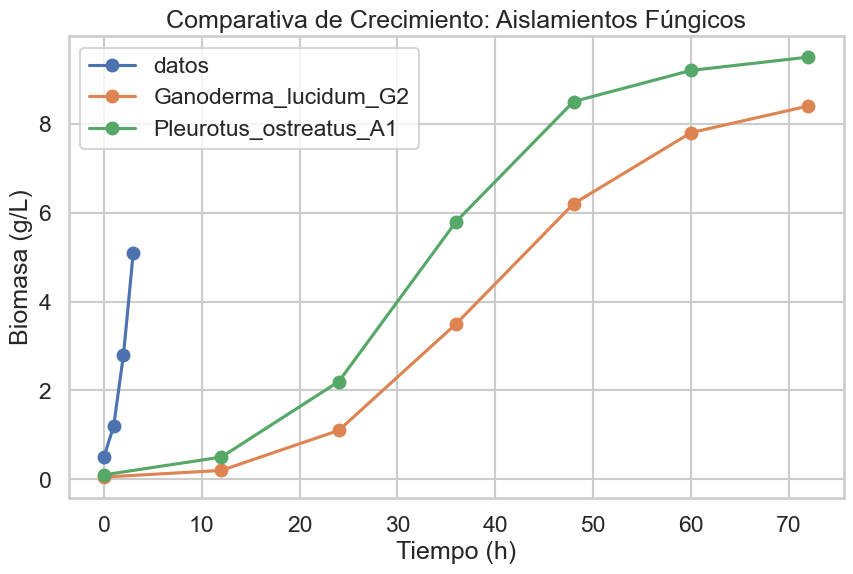

In [3]:
# Celda 3: Comparativa visual de todos los aislamientos
archivos = glob.glob(r'data\*.csv')
plt.figure(figsize=(10, 6))

for archivo in archivos:
    df_temp = pd.read_csv(archivo)
    nombre = os.path.basename(archivo).replace('.csv', '')
    plt.plot(df_temp['tiempo'], df_temp['biomasa'], marker='o', label=nombre)

plt.title("Comparativa de Crecimiento: Aislamientos Fúngicos")
plt.xlabel("Tiempo (h)")
plt.ylabel("Biomasa (g/L)")
plt.legend()
plt.show()

In [4]:
# Celda 4: Cálculo de velocidad máxima por aislamiento
for archivo in archivos:
    df_temp = pd.read_csv(archivo)
    velocidad = np.gradient(df_temp['biomasa'], df_temp['tiempo'])
    nombre = os.path.basename(archivo).replace('.csv', '')
    
    # Encontrar el valor máximo de la tasa
    max_tasa = np.max(velocidad)
    print(f"Aislamiento: {nombre} | Tasa de crecimiento máxima: {max_tasa:.4f} g/L/h")

Aislamiento: datos | Tasa de crecimiento máxima: 2.3000 g/L/h
Aislamiento: Ganoderma_lucidum_G2 | Tasa de crecimiento máxima: 0.2125 g/L/h
Aislamiento: Pleurotus_ostreatus_A1 | Tasa de crecimiento máxima: 0.2625 g/L/h


In [6]:
# --- Celda 5: Análisis cinético avanzado y bondad de ajuste ---
from scipy.optimize import curve_fit # <--- ESTA LÍNEA ES LA CLAVE QUE FALTABA
from sklearn.metrics import r2_score
import numpy as np

print(f"{'='*60}")
print(f"REPORTE TÉCNICO DE CINÉTICA FÚNGICA")
print(f"{'='*60}\n")

# Aseguramos que la función esté definida
def modelo_logistico(t, K, mu, N0):
    return K / (1 + ((K - N0) / N0) * np.exp(-mu * t))

for archivo in archivos:
    df_temp = pd.read_csv(archivo)
    nombre = os.path.basename(archivo).replace('.csv', '')
    
    # Ajuste Logístico
    popt, _ = curve_fit(modelo_logistico, df_temp['tiempo'], df_temp['biomasa'], p0=[max(df_temp['biomasa']), 0.1, min(df_temp['biomasa'])])
    K, mu, N0 = popt
    
    # Test de Bondad de Ajuste
    predicciones = modelo_logistico(df_temp['tiempo'], *popt)
    r2 = r2_score(df_temp['biomasa'], predicciones)
    rmse = np.sqrt(np.mean((df_temp['biomasa'] - predicciones)**2))
    
    print(f"Aislamiento: {nombre}")
    print(f" - Tipo de Ajuste: Modelo Logístico (Sigmoideo)")
    print(f" - Tasa crecimiento específico (mu): {mu:.4f} h^-1")
    print(f" - Capacidad de carga (K): {K:.4f} g/L")
    print(f" - R-cuadrado (Bondad): {r2:.4f}")
    print(f" - Error (RMSE): {rmse:.4f}")
    print(f"{'-'*30}")

REPORTE TÉCNICO DE CINÉTICA FÚNGICA

Aislamiento: datos
 - Tipo de Ajuste: Modelo Logístico (Sigmoideo)
 - Tasa crecimiento específico (mu): 0.6904 h^-1
 - Capacidad de carga (K): -330759619.3672 g/L
 - R-cuadrado (Bondad): 0.9935
 - Error (RMSE): 0.1423
------------------------------
Aislamiento: Ganoderma_lucidum_G2
 - Tipo de Ajuste: Modelo Logístico (Sigmoideo)
 - Tasa crecimiento específico (mu): 0.1196 h^-1
 - Capacidad de carga (K): 8.5121 g/L
 - R-cuadrado (Bondad): 0.9995
 - Error (RMSE): 0.0721
------------------------------
Aislamiento: Pleurotus_ostreatus_A1
 - Tipo de Ajuste: Modelo Logístico (Sigmoideo)
 - Tasa crecimiento específico (mu): 0.1384 h^-1
 - Capacidad de carga (K): 9.4886 g/L
 - R-cuadrado (Bondad): 0.9999
 - Error (RMSE): 0.0375
------------------------------


In [ ]:
# --- Celda 6: Exportación a Excel (Blindada) ---
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import os
import glob

# 1. Definir el modelo y buscar archivos internamente
def modelo_logistico(t, K, mu, N0):
    return K / (1 + ((K - N0) / N0) * np.exp(-mu * t))

archivos = glob.glob(os.path.join('data', '*.csv'))

if not archivos:
    print("Error: No se encontraron archivos en la carpeta 'data'. Verifica la ruta.")
else:
    reporte_data = []
    for archivo in archivos:
        df_temp = pd.read_csv(archivo)
        # Ajuste con valores iniciales ajustados a la escala de biomasa (K=10 es un buen promedio)
        try:
            popt, _ = curve_fit(modelo_logistico, df_temp['tiempo'], df_temp['biomasa'], p0=[10, 0.1, 0.1])
            predicciones = modelo_logistico(df_temp['tiempo'], *popt)
            r2 = r2_score(df_temp['biomasa'], predicciones)
            
            reporte_data.append({
                'Aislamiento': os.path.basename(archivo).replace('.csv', ''),
                'mu': popt[1],
                'K': popt[0],
                'R2': r2
            })
        except Exception as e:
            print(f"Error ajustando {archivo}: {e}")

    # 2. Guardar en Excel
    df_resultados = pd.DataFrame(reporte_data)
    df_resultados.to_excel('Resultados_Cineticos.xlsx', index=False)
    print("Reporte generado exitosamente: 'Resultados_Cineticos.xlsx'")
    print(df_resultados)